# ITNPAI1 Assignment – Comparative Evaluation of BERT and RoBERTa for Sentiment Classification

## Overview
This notebook compares BERT and RoBERTa on two sentiment classification datasets:
- IMDB movie reviews
- TripAdvisor hotel reviews

The task is binary sentiment classification.

## Models
- `bert-base-uncased`
- `roberta-base`

## Datasets
- IMDB dataset loaded from Hugging Face
- TripAdvisor Hotel Reviews dataset downloaded from Kaggle
  Datasets used:

1. IMDB Movie Review Dataset
https://huggingface.co/datasets/stanfordnlp/imdb

2. TripAdvisor Hotel Reviews
https://www.kaggle.com/datasets/andrewmvd/trip-advisor-hotel-reviews

## How to run
1. Install the required libraries.
2. Download/load the datasets.
3. Preprocess the datasets into binary sentiment labels.
4. Convert data into Hugging Face Dataset format.
5. Run training/evaluation cells for each experiment.
6. View final metrics and confusion matrices.

## Reproducibility
- Random seed: 42
- Same train/validation/test logic used across experiments
- Same evaluation metrics used for all models

## Notes
This notebook was cleaned from the development version for submission.

## Install
The following libraries are required for this project:

- Hugging Face Transformers
- Hugging Face Datasets
- Scikit-learn
- PyTorch
- Pandas and NumPy
- Matplotlib

These libraries provide tools for loading datasets, preprocessing text, fine-tuning transformer models, and evaluating classification performance.

In [1]:
!pip install transformers datasets evaluate scikit-learn matplotlib pandas kaggle

## Imports
This section imports the libraries used for data processing, model training, and evaluation.

In [2]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from datasets import load_dataset, Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

C:\Users\jess\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Device Check

In [3]:
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

Torch version: 2.10.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 3070 Laptop GPU


## Load TripAdvisor Dataset

Two datasets are used in this project.

### IMDB Dataset

The IMDB dataset contains **50,000 movie reviews**, labelled as positive or negative sentiment.  
It is a widely used benchmark dataset for sentiment analysis tasks.

Dataset characteristics:
- 25,000 training samples
- 25,000 testing samples
- Balanced positive and negative labels

### TripAdvisor Dataset

The TripAdvisor dataset contains **hotel reviews with ratings from 1 to 5 stars**.

For the purposes of binary sentiment classification:

- Ratings **1–2 → Negative**
- Ratings **4–5 → Positive**
- Rating **3 → Neutral (removed)**

This conversion allows the dataset to be used for the same binary sentiment task as IMDB.

In [4]:
# Download TripAdvisor dataset from Kaggle
!kaggle datasets download -d andrewmvd/trip-advisor-hotel-reviews

# Extract zip file
with zipfile.ZipFile("trip-advisor-hotel-reviews.zip", "r") as zip_ref:
    zip_ref.extractall()

# Load CSV
trip_df = pd.read_csv("tripadvisor_hotel_reviews.csv")

print(trip_df.head())
print(trip_df.shape)
print(trip_df.columns)

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/trip-advisor-hotel-reviews
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
trip-advisor-hotel-reviews.zip: Skipping, found more recently modified local copy (use --force to force download)
                                              Review  Rating
0  nice hotel expensive parking got good deal sta...       4
1  ok nothing special charge diamond member hilto...       2
2  nice rooms not 4* experience hotel monaco seat...       3
3  unique, great stay, wonderful time hotel monac...       5
4  great stay great stay, went seahawk game aweso...       5
(20491, 2)
Index(['Review', 'Rating'], dtype='object')


## Load IMDB dataset

In [7]:
# First connect to hugging face
import os
from getpass import getpass

os.environ["HF_TOKEN"] = getpass("Enter your HuggingFace token: ")

Enter your HuggingFace token:  ········


In [8]:
imdb = load_dataset("imdb")

imdb_train = pd.DataFrame(imdb["train"])
imdb_test = pd.DataFrame(imdb["test"])

print(imdb_train.head())
print(imdb_train.shape)
print(imdb_test.shape)

                                                text  label
0  I rented I AM CURIOUS-YELLOW from my video sto...      0
1  "I Am Curious: Yellow" is a risible and preten...      0
2  If only to avoid making this type of film in t...      0
3  This film was probably inspired by Godard's Ma...      0
4  Oh, brother...after hearing about this ridicul...      0
(25000, 2)
(25000, 2)


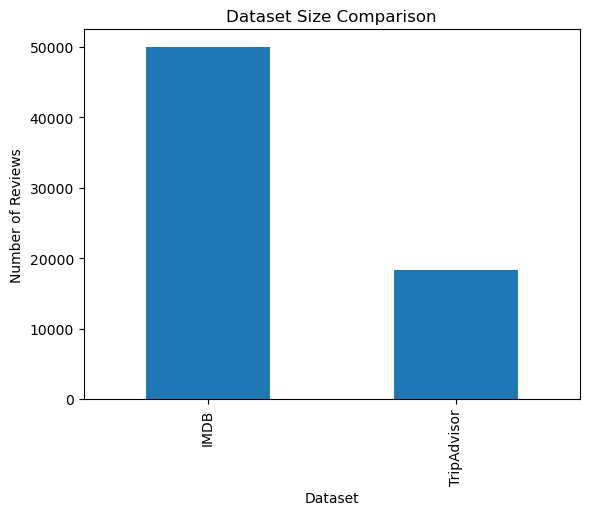

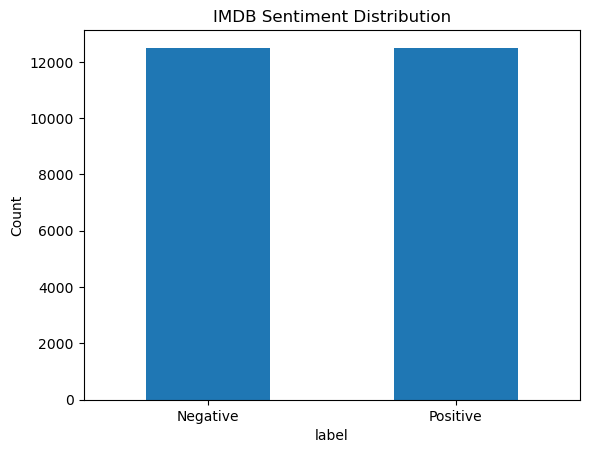

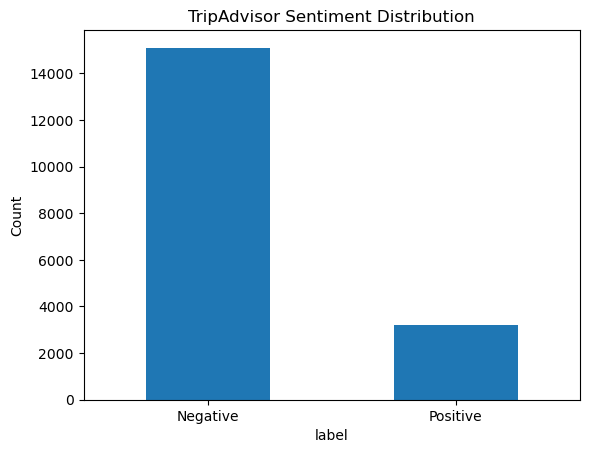

In [37]:
# Dataset exploration visualisations
dataset_sizes = pd.DataFrame({
    "Dataset": ["IMDB", "TripAdvisor"],
    "Samples": [len(imdb_train) + len(imdb_test), len(trip_df)]
})

dataset_sizes.plot(
    x="Dataset",
    y="Samples",
    kind="bar",
    legend=False,
    title="Dataset Size Comparison"
)

plt.ylabel("Number of Reviews")
plt.show()

# Class Distribution IMDB 

imdb_train["label"].value_counts().plot(
    kind="bar",
    title="IMDB Sentiment Distribution"
)

plt.xticks([0,1],["Negative","Positive"],rotation=0)
plt.ylabel("Count")
plt.show()

# Class Distribution TripAdvisor

trip_df["label"].value_counts().plot(
    kind="bar",
    title="TripAdvisor Sentiment Distribution"
)

plt.xticks([0,1],["Negative","Positive"],rotation=0)
plt.ylabel("Count")
plt.show()

## 3. Data Preparation 

The data preparation stage converts raw review text into a format suitable for machine learning.

Key steps include:

1. Converting TripAdvisor star ratings into binary sentiment labels
2. Removing neutral reviews
3. Splitting datasets into training, validation, and test sets
4. Converting the datasets into Hugging Face Dataset format
5. Tokenising text using the appropriate tokenizer for each model

These steps ensure that both datasets are prepared consistently for model training.

In [9]:
# Remove neutral reviews (rating = 3)
trip_df = trip_df[trip_df["Rating"] != 3].copy()

# Convert ratings to binary sentiment
# 1–2 = negative (0), 4–5 = positive (1)
trip_df["label"] = trip_df["Rating"].apply(lambda x: 1 if x >= 4 else 0)

# Rename review text column
trip_df = trip_df.rename(columns={"Review": "text"})

# Keep only needed columns
trip_df = trip_df[["text", "label"]]

print(trip_df.head())
print(trip_df["label"].value_counts())

                                                text  label
0  nice hotel expensive parking got good deal sta...      1
1  ok nothing special charge diamond member hilto...      0
3  unique, great stay, wonderful time hotel monac...      1
4  great stay great stay, went seahawk game aweso...      1
5  love monaco staff husband stayed hotel crazy w...      1
label
1    15093
0     3214
Name: count, dtype: int64


In [11]:
## Split datasets

# IMDB: make validation split from training set
imdb_train_df, imdb_val_df = train_test_split(
    imdb_train,
    test_size=0.1,
    stratify=imdb_train["label"],
    random_state=42
)

# Keep only required columns
imdb_train_df = imdb_train_df[["text", "label"]]
imdb_val_df = imdb_val_df[["text", "label"]]
imdb_test = imdb_test[["text", "label"]]

# TripAdvisor: create train, validation, test
trip_train, trip_temp = train_test_split(
    trip_df,
    test_size=0.2,
    stratify=trip_df["label"],
    random_state=42
)

trip_val, trip_test = train_test_split(
    trip_temp,
    test_size=0.5,
    stratify=trip_temp["label"],
    random_state=42
)

print("IMDB train:", imdb_train_df.shape)
print("IMDB val:", imdb_val_df.shape)
print("IMDB test:", imdb_test.shape)

print("\nTripAdvisor train:", trip_train.shape)
print("TripAdvisor val:", trip_val.shape)
print("TripAdvisor test:", trip_test.shape)

IMDB train: (22500, 2)
IMDB val: (2500, 2)
IMDB test: (25000, 2)

TripAdvisor train: (14645, 2)
TripAdvisor val: (1831, 2)
TripAdvisor test: (1831, 2)


In [12]:
# Convert to hugging face datasets

imdb_ds = DatasetDict({
    "train": Dataset.from_pandas(imdb_train_df.reset_index(drop=True)),
    "validation": Dataset.from_pandas(imdb_val_df.reset_index(drop=True)),
    "test": Dataset.from_pandas(imdb_test.reset_index(drop=True))
})

trip_ds = DatasetDict({
    "train": Dataset.from_pandas(trip_train.reset_index(drop=True)),
    "validation": Dataset.from_pandas(trip_val.reset_index(drop=True)),
    "test": Dataset.from_pandas(trip_test.reset_index(drop=True))
})

print(imdb_ds)
print(trip_ds)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 22500
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2500
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
})
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 14645
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1831
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1831
    })
})


In [13]:
# Metrics function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )
    accuracy = accuracy_score(labels, preds)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

## 4. Modelling

Two transformer-based architectures are evaluated:

### BERT
BERT (Bidirectional Encoder Representations from Transformers) is a transformer model designed to understand context in text using bidirectional attention.

### RoBERTa
RoBERTa (Robustly Optimized BERT Approach) is an improved version of BERT that was trained with larger datasets and optimized training strategies.

Both models are fine-tuned for binary sentiment classification using the Hugging Face Transformers framework.

Each model is trained on both datasets:

1. BERT on IMDB
2. BERT on TripAdvisor
3. RoBERTa on IMDB
4. RoBERTa on TripAdvisor

In [14]:
#Tokenisation function

def tokenize_dataset(dataset_dict, model_name, max_length=256):
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize_function(examples):
        return tokenizer(
            examples["text"],
            truncation=True,
            padding="max_length",
            max_length=max_length
        )

    tokenized_ds = dataset_dict.map(tokenize_function, batched=True)
    tokenized_ds = tokenized_ds.remove_columns(["text"])
    tokenized_ds.set_format("torch")

    return tokenized_ds, tokenizer

In [15]:
# Tokenise datasets

# BERT tokenized datasets
imdb_bert_ds, bert_tokenizer = tokenize_dataset(imdb_ds, "bert-base-uncased")
trip_bert_ds, _ = tokenize_dataset(trip_ds, "bert-base-uncased")

# RoBERTa tokenized datasets
imdb_roberta_ds, roberta_tokenizer = tokenize_dataset(imdb_ds, "roberta-base")
trip_roberta_ds, _ = tokenize_dataset(trip_ds, "roberta-base")

print("Tokenization complete.")

Map: 100%|██████████| 1831/1831 [00:00<00:00, 9131.04 examples/s]

Tokenization complete.


In [17]:
#Evaluation metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="binary",
        zero_division=0
    )
    accuracy = accuracy_score(labels, preds)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [25]:
# Trainer Builder
def build_trainer(model_name, dataset_dict, output_dir):
    
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2
    )

    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=1,     
        weight_decay=0.01,
        save_total_limit=1,
        report_to="none",
        seed=42,
        disable_tqdm=False    
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=dataset_dict["train"],
        eval_dataset=dataset_dict["validation"],
        compute_metrics=compute_metrics
    )

    return trainer

In [23]:
# BERT on IMDB
bert_imdb_trainer = build_trainer(
    model_name="bert-base-uncased",
    dataset_dict=imdb_bert_ds,
    output_dir="./bert_imdb"
)

bert_imdb_trainer.train()

bert_imdb_predictions = bert_imdb_trainer.predict(imdb_bert_ds["test"])

bert_imdb_true = bert_imdb_predictions.label_ids
bert_imdb_pred = np.argmax(bert_imdb_predictions.predictions, axis=1)

precision, recall, f1, _ = precision_recall_fscore_support(
    bert_imdb_true,
    bert_imdb_pred,
    average="binary",
    zero_division=0
)

accuracy = accuracy_score(bert_imdb_true, bert_imdb_pred)

bert_imdb_results = {
    "eval_accuracy": accuracy,
    "eval_precision": precision,
    "eval_recall": recall,
    "eval_f1": f1
}

bert_imdb_trainer.save_model("bert_imdb_model")

print("BERT on IMDB")
print(bert_imdb_results)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6622.39it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider tr

{'loss': '0.3539', 'grad_norm': '52.69', 'learning_rate': '2.501e-05', 'epoch': '1'}
{'eval_loss': '0.281', 'eval_accuracy': '0.9032', 'eval_precision': '0.8994', 'eval_recall': '0.908', 'eval_f1': '0.9037', 'eval_runtime': '45.02', 'eval_samples_per_second': '55.54', 'eval_steps_per_second': '6.953', 'epoch': '1'}


Writing model shards: 100%|██████████| 1/1 [00:04<00:00,  4.04s/it]


{'loss': '0.1732', 'grad_norm': '0.06251', 'learning_rate': '8.887e-09', 'epoch': '2'}
{'eval_loss': '0.351', 'eval_accuracy': '0.9176', 'eval_precision': '0.9143', 'eval_recall': '0.9216', 'eval_f1': '0.9179', 'eval_runtime': '41.2', 'eval_samples_per_second': '60.69', 'eval_steps_per_second': '7.598', 'epoch': '2'}


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.10it/s]


{'train_runtime': '2167', 'train_samples_per_second': '20.76', 'train_steps_per_second': '2.596', 'train_loss': '0.2635', 'epoch': '2'}


There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

BERT on IMDB
{'eval_accuracy': 0.9198, 'eval_precision': 0.9143308330043427, 'eval_recall': 0.9264, 'eval_f1': 0.9203258493939996}


In [24]:
bert_imdb_results = {
    "eval_accuracy": 0.9198,
    "eval_precision": 0.9143308330043427,
    "eval_recall": 0.9264,
    "eval_f1": 0.9203258493939996
}

In [26]:
# BERT on TripAdvisor
bert_trip_trainer = build_trainer(
    model_name="bert-base-uncased",
    dataset_dict=trip_bert_ds,
    output_dir="./bert_trip"
)

# Train the model
bert_trip_trainer.train()

# Predict on the test set
bert_trip_predictions = bert_trip_trainer.predict(trip_bert_ds["test"])

# Extract labels and predictions
bert_trip_true = bert_trip_predictions.label_ids
bert_trip_pred = np.argmax(bert_trip_predictions.predictions, axis=1)

# Compute metrics manually
precision, recall, f1, _ = precision_recall_fscore_support(
    bert_trip_true,
    bert_trip_pred,
    average="binary",
    zero_division=0
)

accuracy = accuracy_score(bert_trip_true, bert_trip_pred)

bert_trip_results = {
    "eval_accuracy": accuracy,
    "eval_precision": precision,
    "eval_recall": recall,
    "eval_f1": f1
}

# Save model 
bert_trip_trainer.save_model("bert_trip_model")

print("BERT on TripAdvisor")
print(bert_trip_results)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6159.40it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider tr

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.168609,0.069630,0.978700,0.982928,0.991391,0.987141


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.51s/it]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.34s/it]

BERT on TripAdvisor
{'eval_accuracy': 0.9628618241398144, 'eval_precision': 0.9706074461136512, 'eval_recall': 0.9847581179589132, 'eval_f1': 0.9776315789473684}


In [27]:
# RoBERTa on IMDB
roberta_imdb_trainer = build_trainer(
    model_name="roberta-base",
    dataset_dict=imdb_roberta_ds,
    output_dir="./roberta_imdb"
)

# Train the model
roberta_imdb_trainer.train()

# Predict on test set
roberta_imdb_predictions = roberta_imdb_trainer.predict(imdb_roberta_ds["test"])

# Extract predictions
roberta_imdb_true = roberta_imdb_predictions.label_ids
roberta_imdb_pred = np.argmax(roberta_imdb_predictions.predictions, axis=1)

# Compute evaluation metrics
precision, recall, f1, _ = precision_recall_fscore_support(
    roberta_imdb_true,
    roberta_imdb_pred,
    average="binary",
    zero_division=0
)

accuracy = accuracy_score(roberta_imdb_true, roberta_imdb_pred)

roberta_imdb_results = {
    "eval_accuracy": accuracy,
    "eval_precision": precision,
    "eval_recall": recall,
    "eval_f1": f1
}

# Save model 
roberta_imdb_trainer.save_model("roberta_imdb_model")

print("RoBERTa on IMDB")
print(roberta_imdb_results)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 3868.94it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.348479,0.256081,0.928000,0.930064,0.925600,0.927827


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.62s/it]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.69s/it]

RoBERTa on IMDB
{'eval_accuracy': 0.92812, 'eval_precision': 0.9261766345464681, 'eval_recall': 0.9304, 'eval_f1': 0.9282835135890171}


In [28]:
# RoBERTa on TripAdvisor
roberta_trip_trainer = build_trainer(
    model_name="roberta-base",
    dataset_dict=trip_roberta_ds,
    output_dir="./roberta_trip"
)

# Train the model
roberta_trip_trainer.train()

# Predict on test set
roberta_trip_predictions = roberta_trip_trainer.predict(trip_roberta_ds["test"])

# Extract predictions
roberta_trip_true = roberta_trip_predictions.label_ids
roberta_trip_pred = np.argmax(roberta_trip_predictions.predictions, axis=1)

# Compute evaluation metrics
precision, recall, f1, _ = precision_recall_fscore_support(
    roberta_trip_true,
    roberta_trip_pred,
    average="binary",
    zero_division=0
)

accuracy = accuracy_score(roberta_trip_true, roberta_trip_pred)

roberta_trip_results = {
    "eval_accuracy": accuracy,
    "eval_precision": precision,
    "eval_recall": recall,
    "eval_f1": f1
}

# Save model
roberta_trip_trainer.save_model("roberta_trip_model")

print("RoBERTa on TripAdvisor")
print(roberta_trip_results)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4737.18it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.335058,0.135089,0.959039,0.960822,0.990728,0.975546


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.51s/it]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.47s/it]

RoBERTa on TripAdvisor
{'eval_accuracy': 0.9508465319497542, 'eval_precision': 0.9539347408829175, 'eval_recall': 0.9880715705765407, 'eval_f1': 0.970703125}


## 5. Evaluation 

Model performance is evaluated using several classification metrics:

- **Accuracy** – overall prediction correctness
- **Precision** – proportion of positive predictions that were correct
- **Recall** – proportion of true positives correctly identified
- **F1-score** – harmonic mean of precision and recall

Confusion matrices are also used to visualise classification errors. 

These metrics allow comparison between the two architectures across both datasets.

In [30]:
# Create a results comparison table
results_df = pd.DataFrame([
    {
        "Model": "BERT",
        "Dataset": "IMDB",
        "Accuracy": bert_imdb_results["eval_accuracy"],
        "Precision": bert_imdb_results["eval_precision"],
        "Recall": bert_imdb_results["eval_recall"],
        "F1": bert_imdb_results["eval_f1"]
    },
    {
        "Model": "BERT",
        "Dataset": "TripAdvisor",
        "Accuracy": bert_trip_results["eval_accuracy"],
        "Precision": bert_trip_results["eval_precision"],
        "Recall": bert_trip_results["eval_recall"],
        "F1": bert_trip_results["eval_f1"]
    },
    {
        "Model": "RoBERTa",
        "Dataset": "IMDB",
        "Accuracy": roberta_imdb_results["eval_accuracy"],
        "Precision": roberta_imdb_results["eval_precision"],
        "Recall": roberta_imdb_results["eval_recall"],
        "F1": roberta_imdb_results["eval_f1"]
    },
    {
        "Model": "RoBERTa",
        "Dataset": "TripAdvisor",
        "Accuracy": roberta_trip_results["eval_accuracy"],
        "Precision": roberta_trip_results["eval_precision"],
        "Recall": roberta_trip_results["eval_recall"],
        "F1": roberta_trip_results["eval_f1"]
    }
])

results_df

,Model,Dataset,Accuracy,Precision,Recall,F1
0,BERT,IMDB,0.919800,0.914331,0.926400,0.920326
1,BERT,TripAdvisor,0.962862,0.970607,0.984758,0.977632
2,RoBERTa,IMDB,0.928120,0.926177,0.930400,0.928284
3,RoBERTa,TripAdvisor,0.950847,0.953935,0.988072,0.970703


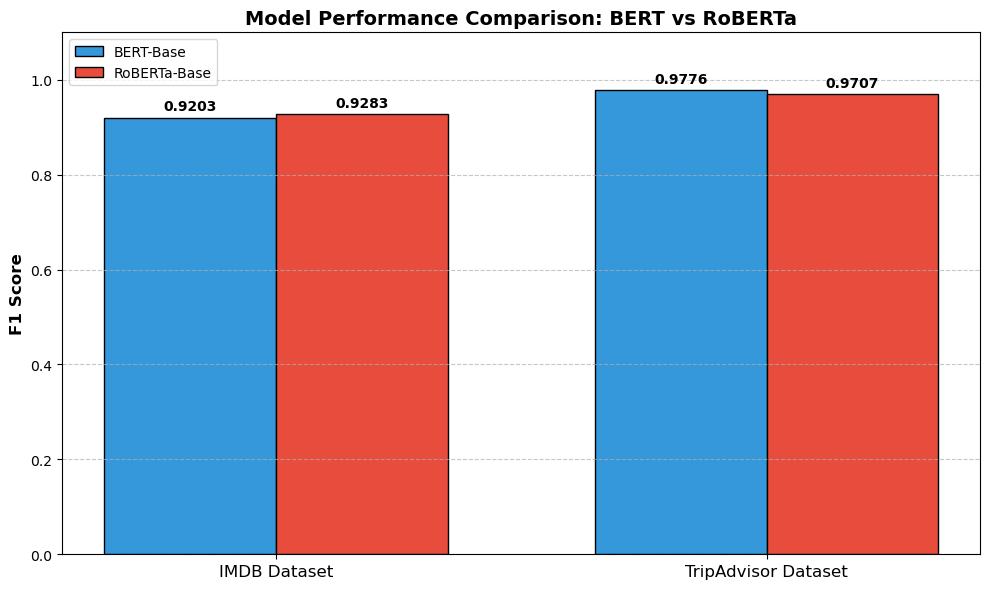

In [36]:
labels = ['IMDB Dataset', 'TripAdvisor Dataset']

# Accessing the 'eval_f1' key directly from the results
bert_scores = [
    bert_imdb_results['eval_f1'], 
    bert_trip_results['eval_f1']
]
roberta_scores = [
    roberta_imdb_results['eval_f1'], 
    roberta_trip_results['eval_f1']
]

x = np.arange(len(labels))  
width = 0.35  

fig, ax = plt.subplots(figsize=(10, 6))

# 2. Create the grouped bars
rects1 = ax.bar(x - width/2, bert_scores, width, label='BERT-Base', color='#3498db', edgecolor='black')
rects2 = ax.bar(x + width/2, roberta_scores, width, label='RoBERTa-Base', color='#e74c3c', edgecolor='black')

# 3. Report styling
ax.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison: BERT vs RoBERTa', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0, 1.1) 
ax.legend()

# 4. Data labels 
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

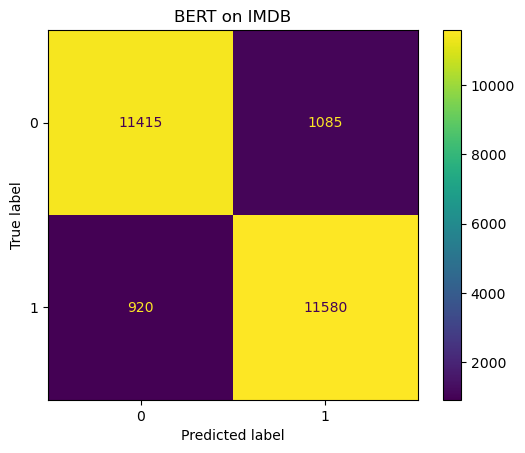

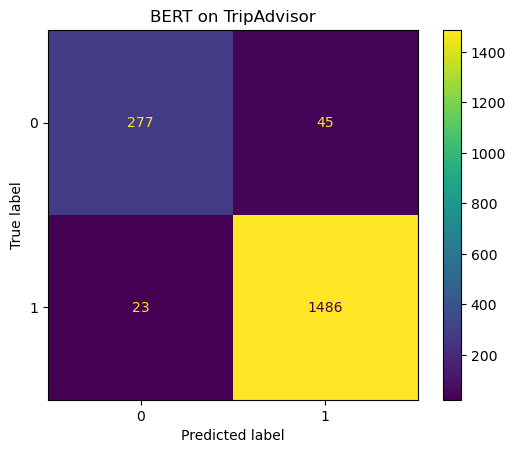

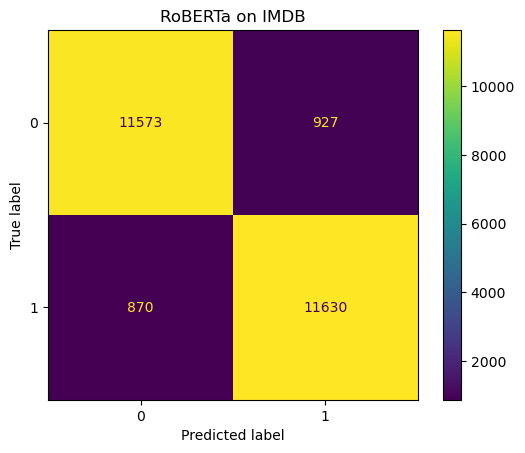

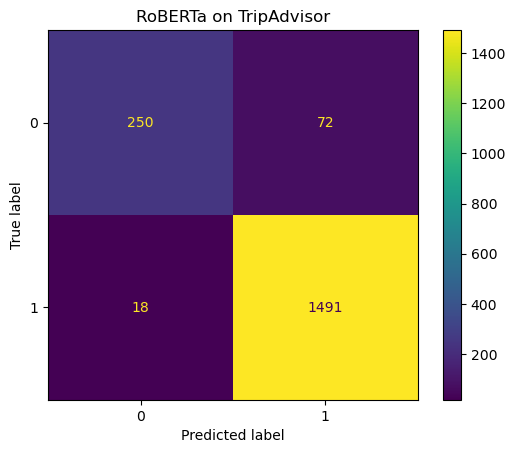

In [31]:
# Create a confusion matrix function
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(title)
    plt.show()

# Plot all confusion matrices
plot_conf_matrix(bert_imdb_true, bert_imdb_pred, "BERT on IMDB")
plot_conf_matrix(bert_trip_true, bert_trip_pred, "BERT on TripAdvisor")
plot_conf_matrix(roberta_imdb_true, roberta_imdb_pred, "RoBERTa on IMDB")
plot_conf_matrix(roberta_trip_true, roberta_trip_pred, "RoBERTa on TripAdvisor")

### Results Summary

The comparison table and confusion matrices allow direct evaluation of model performance across both datasets.

The results can be used to determine:

- which model achieved the highest overall accuracy
- whether RoBERTa consistently outperformed BERT
- whether sentiment classification was easier on one dataset than the other
- where each model made classification errors